# 03 — Custom CNN
In the previous stage, we established a performance floor using a shallow CNN. However, artistic styles in the WikiArt dataset are defined by complex textures, color gradients, and brushstroke patterns that require a deeper hierarchy of features.

In this notebook, we implement a Custom CNN designed specifically for this task, incorporating:
1. **Depth**: More convolutional layers to capture high-level artistic features.
2. **Batch Normalization**: To stabilize and accelerate the training process.
3. **Global Average Pooling**: To reduce the number of parameters and combat overfitting.
4. **Advanced Dropout**: To ensure the model generalizes well to unseen paintings.

This notebook covers:
1. **Dataset Integration**: Loading the pre-processed WikiArt subset using the build_datasets pipeline.
2. **Hyperparameter Tuning**: Using RandomSearch in order to explore the hyperparameter space.
3. **Advanced Training**: Implementing Model Checkpoints and Early Stopping to capture the best performing weights.
4. **Performance Analysis**: Saving the optimized model and training logs for cross-model evaluation.

In [ ]:
import sys
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import keras_tuner as kt

sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets
from src.models.custom_cnn import custom_model_builder

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50 # Increased epochs as the model is deeper

## 1. Loading the Pre-processed WikiArt Dataset

In [8]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir="../data/splits",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_processed=True,
    processed_dir="../data/processed"
)

print(f"Data pipeline ready for {NUM_CLASSES} classes.")

Data pipeline ready for 23 classes.


## 2. Hyperparameter Tuning 
To optimize the Custom CNN, we use **Random Search**. This allows us to efficiently explore 
the hyperparameter space (Learning Rate, Dropout, and Filters) to find the best configuration 
for the WikiArt dataset without the exhaustive cost of a Grid Search.

In [ ]:
tuner = kt.RandomSearch(
    lambda hp: custom_model_builder(hp, num_classes=NUM_CLASSES),
    objective='val_accuracy',
    max_trials=2,
    directory='../results/tuning',    
    project_name='wikiart_custom',
    overwrite=True,
    logger=None           
)

tuner.search(train_ds, epochs=10, validation_data=val_ds)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Hyperparameters to use:
- Best LR: {best_hps.get('learning_rate')}
- Best Dropout: {best_hps.get('dropout_rate')}
- Best Initial Filters: {best_hps.get('num_filters')}
""")

Trial 2 Complete [00h 32m 14s]
val_accuracy: 0.2013992965221405

Best val_accuracy So Far: 0.2438780665397644
Total elapsed time: 01h 01m 24s

Hyperparameters to use:
- Best LR: 0.0015620297094023163
- Best Dropout: 0.4
- Best Initial Filters: 16



## 3. Advanced Training
For this model, we are using a more robust training strategy:
* **Early Stopping**: Set to 5 epochs of patience to avoid wasting computational resources if the model stagnates.
* **Model Checkpoints**: Automatically saving the best version of the model based on `val_loss`.

In [10]:
os.makedirs('../results/logs', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

model = tuner.hypermodel.build(best_hps)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('../results/logs/custom_cnn.csv'),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='../results/models/custom_cnn.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/2
292/292 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - accuracy: 0.2294 - loss: 2.6467 - val_accuracy: 0.1099 - val_loss: 3.2424
Epoch 2/2
292/292 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.3002 - loss: 2.3648 - val_accuracy: 0.3263 - val_loss: 2.2168


## 4. Performance Analysis
We compare the learning curves of this Custom CNN against the baseline history. We expect to see a smoother loss decrease due to Batch Normalization and higher peak accuracy due to the added depth.

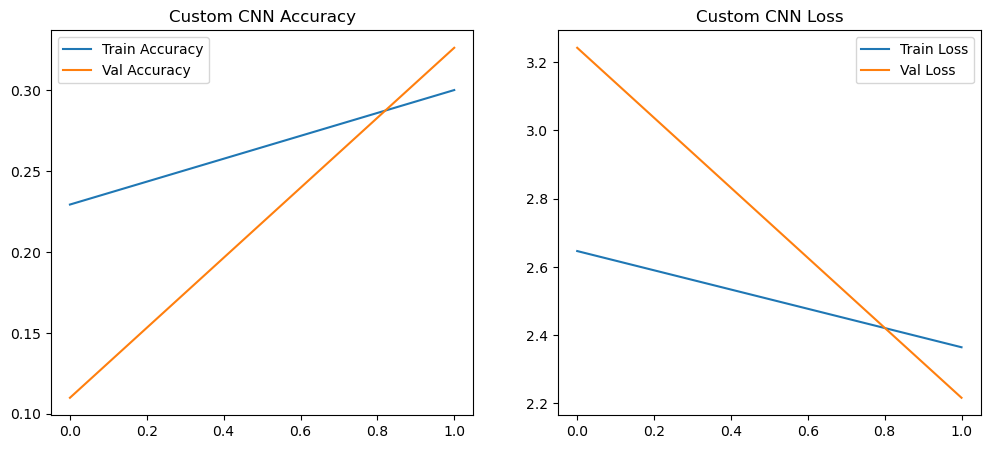

In [11]:
def plot_custom_results(history, filename="custom_cnn_learning_curves.png"):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Custom CNN Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Custom CNN Loss')
    plt.legend()
    
    os.makedirs('../results/figures', exist_ok=True)
    plt.savefig(f'../results/figures/{filename}', dpi=300)
    plt.show()

plot_custom_results(history)